# Work With Standardized Spectral File For ESSP4
Standardized spectra have filenames of the form: `DS#.###_spec_<<inst>>.fits`

For example, the twelfth (012) observation from data set three (3), taken by the HARPS-N instrument will have the file name: `DS3.012_spec_harpsn.fits`

In [2]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [3]:
# Specify file name
# (I'll select a random file from a specified data set)

# Specify where all the data set folders (i.e. DS1) are, here saved into "essp_dir" variable
essp_dir = '/work2/lbuc/data/ESSP4/ESSP4'

# Specify data set number
dset_num = 1

# Select a file at random from all files in the data set
file_list = glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*.fits'))
file_name = np.random.choice(file_list)

In [4]:
hdus = fits.open(file_name)
hdus.info()

Filename: /work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.284_spec_expres.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      21   ()      
  1  WAVELENGTH    1 ImageHDU         8   (7920, 87)   float64   
  2  FLUX          1 ImageHDU         8   (7920, 87)   float64   
  3  UNCERTAINTY    1 ImageHDU         8   (7920, 87)   float64   
  4  CONTINUUM     1 ImageHDU         8   (7920, 87)   float64   
  5  BLAZE         1 ImageHDU         8   (7920, 87)   float64   
  6  COMMON_MASK    1 ImageHDU         8   (7920, 87)   int64   
  7  TELLURIC_MASK    1 ImageHDU         8   (7920, 87)   int64   


In [5]:
# Each data array has shape (number of orders, number of pixels)
num_ord, num_pix = hdus['wavelength'].data.shape
num_ord, num_pix

(73, 4096)

## Continuum Normalized Spectra

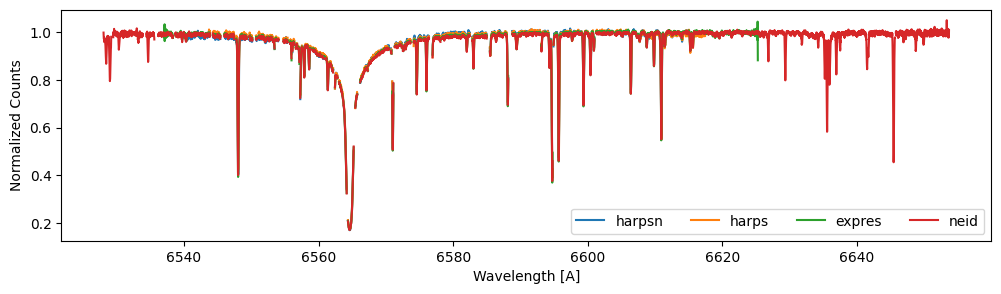

In [6]:
# Plot Echelle Order 93 (i.e. Standard Relative Order 161-93=68)
nord = 161-93

plt.figure(figsize=(12,3))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')
for inst in ['harpsn','harps','expres','neid']:
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    cont = hdus['continuum'].data.copy()
    hdus.close()
    
    plt.plot(wave[nord],spec[nord]/cont[nord],label=inst)
    hdus.close()
plt.legend(loc=4,ncol=4)

## Remove Orders With Only NaNs
Here is a simple function for finding which orders have been added and contain only NaNs.  This is demonstrated by employing the resultant mask on an example file from each of the four instruments and printing out the shape of the resultant array with and without the mask.

In [7]:
def getNanMask(flux):
    return np.sum(np.isfinite(flux),axis=1)>0

In [8]:
for inst in ['harpsn','harps','expres','neid']:
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    og_flux = hdus['flux'].data
    flux = og_flux[getNanMask(og_flux)]
    print(inst)
    print('Original Array Shape: ',og_flux.shape)
    print('Masked Array Shape: ',flux.shape)
    print('--------------------------------')
    hdus.close()

harpsn
Original Array Shape:  (73, 4096)
Masked Array Shape:  (69, 4096)
--------------------------------
harps
Original Array Shape:  (73, 4096)
Masked Array Shape:  (71, 4096)
--------------------------------
expres
Original Array Shape:  (87, 7920)
Masked Array Shape:  (85, 7920)
--------------------------------
neid
Original Array Shape:  (93, 9216)
Masked Array Shape:  (93, 9216)
--------------------------------


## Uncertainty
You can use the `blaze` to recover the original counts of each spectrum.  You will also notice that the uncertainty, which is reported slightly differently by each instrument's DRP, is approximately the square root of the original counts of each spectrum.

This Means:
1) For weighting spectral values by photon noise, use the blaze keyword; otherwise use the given uncertainties.
1) When using the uncertainty values in a situation in which absolute value matters, be sure to scale the uncertainties how the spectral values are scaled (e.g., if the spectrum is continuum normalized, also continuum normalize the uncertainties)

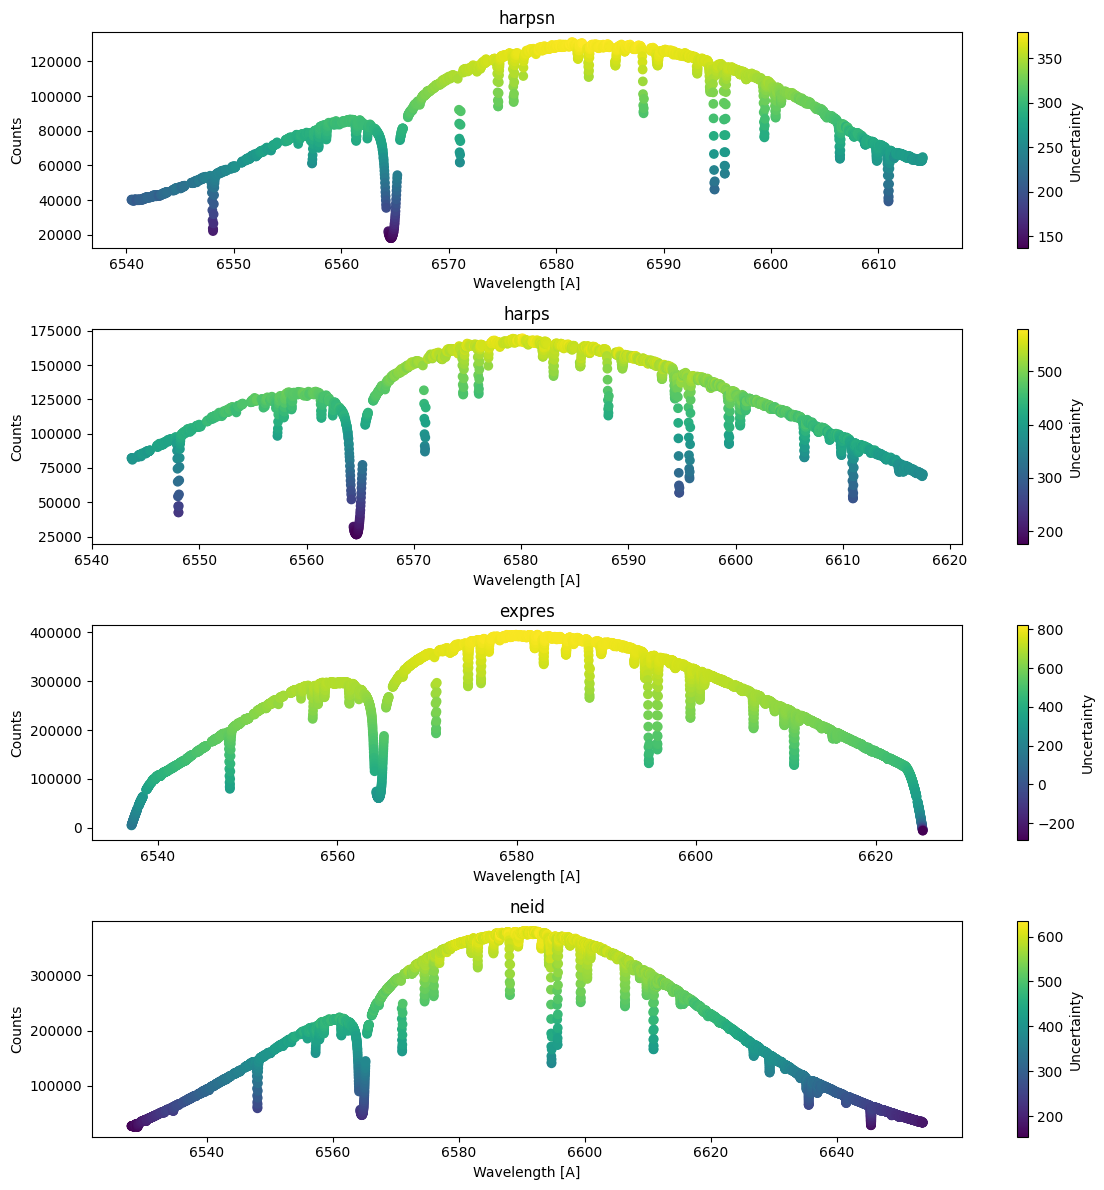

In [9]:
# Plot Echelle Order 93 (i.e. Standard Relative Order 161-93=68)
nord = 161-93

fig, axes = plt.subplots(4,1,figsize=(12,12))
for iinst,inst in enumerate(['harpsn','harps','expres','neid']):
    ax = axes[iinst]
    ax.set_title(inst)
    ax.set_xlabel('Wavelength [A]')
    ax.set_ylabel('Counts')
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    file = np.sort(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))[0]
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    unct = hdus['uncertainty'].data.copy()
    blaz = hdus['blaze'].data.copy()
    hdus.close()
    
    cbar = ax.scatter(wave[nord],spec[nord],c=unct[nord])
    fig.colorbar(cbar,ax=ax,label='Uncertainty')
fig.tight_layout()

## Wavelengths Common to All Four Instruments

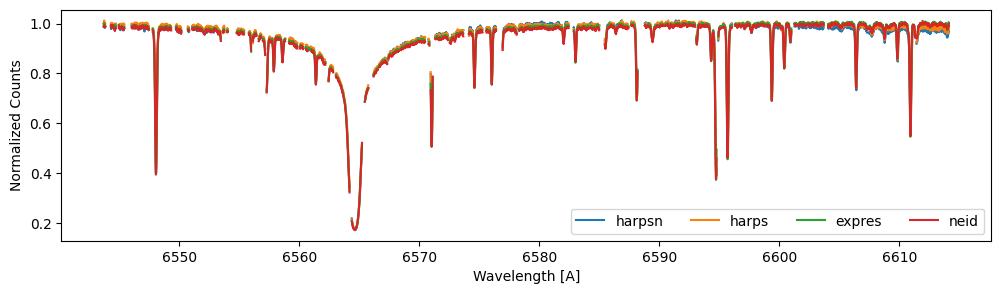

In [10]:
# Plot Echelle Order 93 (i.e. Standard Relative Order 161-93=68)
nord = 161-93

plt.figure(figsize=(12,3))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')
for inst in ['harpsn','harps','expres','neid']:
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    cont = hdus['continuum'].data.copy()
    cmask = hdus['common_mask'].data.astype(bool).copy()
    hdus.close()
    
    nord_mask = cmask[nord]
    plt.plot(wave[nord][nord_mask],(spec[nord]/cont[nord])[nord_mask],label=inst)
    hdus.close()
plt.legend(loc=4,ncol=4)

## Telluric Mask
The `telluric_mask` data product is 1 where the spectrum has been masked out becasue of the presence of tellurics.  In other words, wherever `telluric_mask` is 1, the spectrum is a `NaN`.  The below figure demonstrates this.

The inverse of `telluric_mask` can be used to return only values in an order with true values.

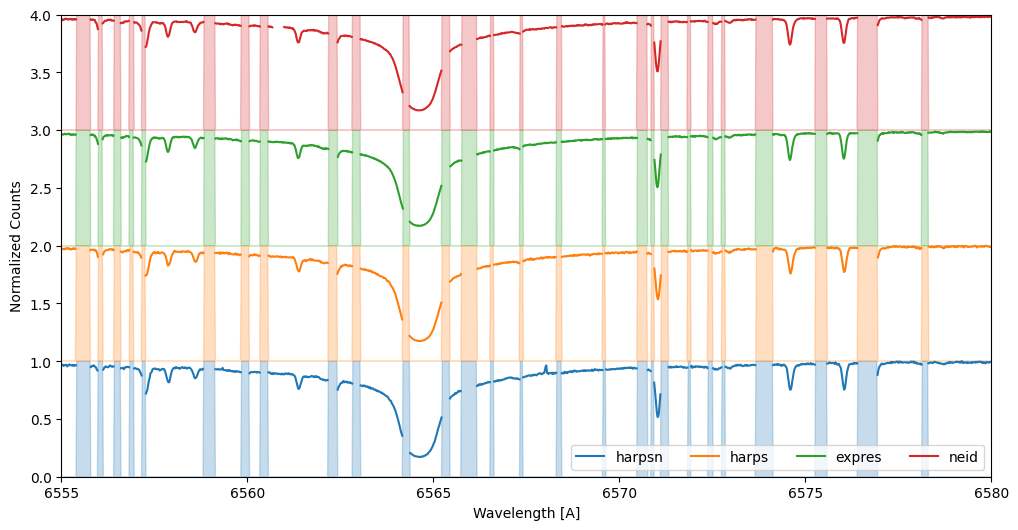

In [11]:
# Plot Echelle Order 93 (i.e. Standard Relative Order 161-93=68)
nord = 161-93

plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')
for iinst,inst in enumerate(['harpsn','harps','expres','neid']):
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    cont = hdus['continuum'].data.copy()
    tmask = hdus['telluric_mask'].data.copy()
    hdus.close()
    
    plt.plot(wave[nord],spec[nord]/cont[nord]+iinst,label=inst)
    plt.fill_between(wave[nord],iinst,iinst+tmask[nord],color=f'C{iinst}',alpha=0.25)
plt.xlim(6555,6580)
plt.ylim(0,4)
plt.legend(loc=4,ncol=4)

## Merged Spectra

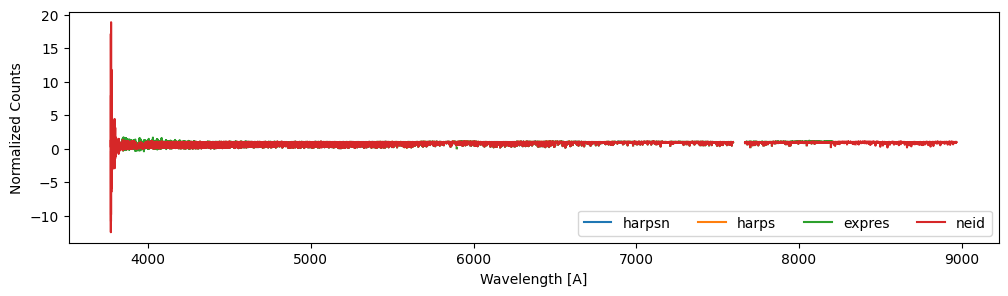

In [12]:
plt.figure(figsize=(12,3))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')
for inst in ['harpsn','harps','expres','neid']:
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Merged',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    hdus.close()
    
    plt.plot(wave,spec,label=inst)
    hdus.close()
plt.legend(loc=4,ncol=4)

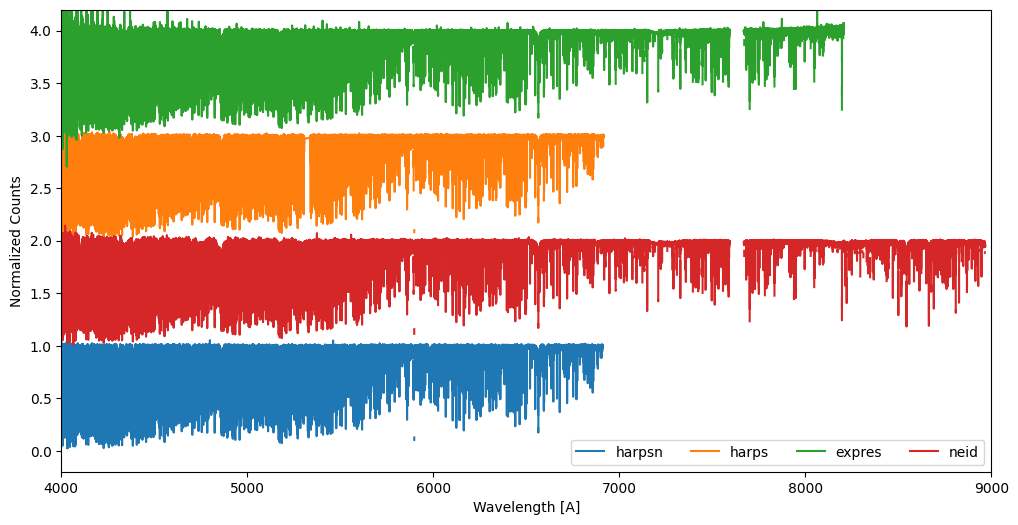

In [13]:
plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')

for inst in ['harpsn','harps','expres','neid']:


    if inst == 'harpsn':
        offset = 0
    elif inst == 'neid':
        offset = 1
    elif inst == 'harps':
        offset = 2
    elif inst == 'expres':
        offset = 3
    
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Merged',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    hdus.close()
    
    plt.plot(wave,spec+offset,label=inst)
    plt.xlim(4000, 9000)
    plt.ylim(-0.2, 4.2)
    hdus.close()
plt.legend(loc=4,ncol=4)
plt.show()

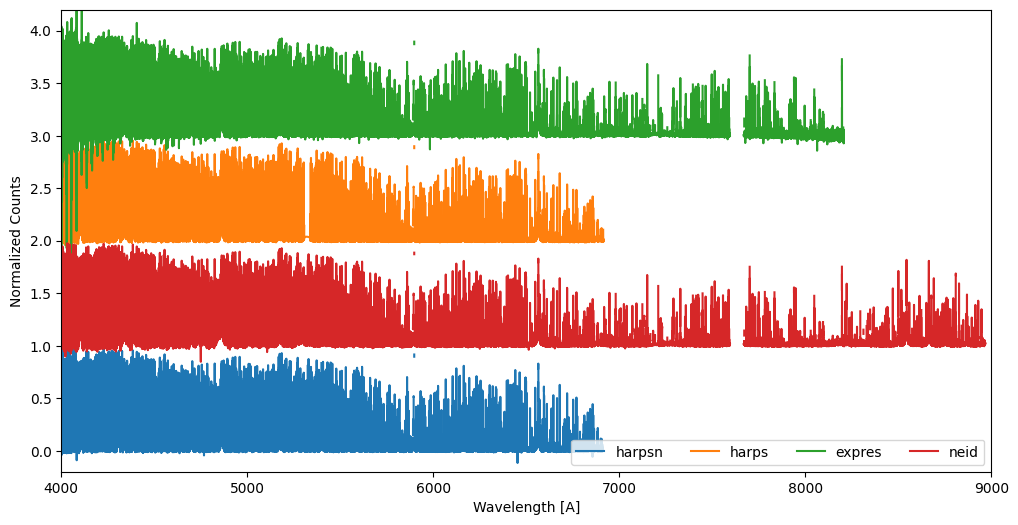

In [14]:
plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')

for inst in ['harpsn','harps','expres','neid']:


    if inst == 'harpsn':
        offset = 0
    elif inst == 'neid':
        offset = 1
    elif inst == 'harps':
        offset = 2
    elif inst == 'expres':
        offset = 3
    
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Merged',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    hdus.close()
    
    plt.plot(wave,1-spec+offset,label=inst)
    plt.xlim(4000, 9000)
    plt.ylim(-0.2, 4.2)
    hdus.close()
plt.legend(loc=4,ncol=4)
plt.show()

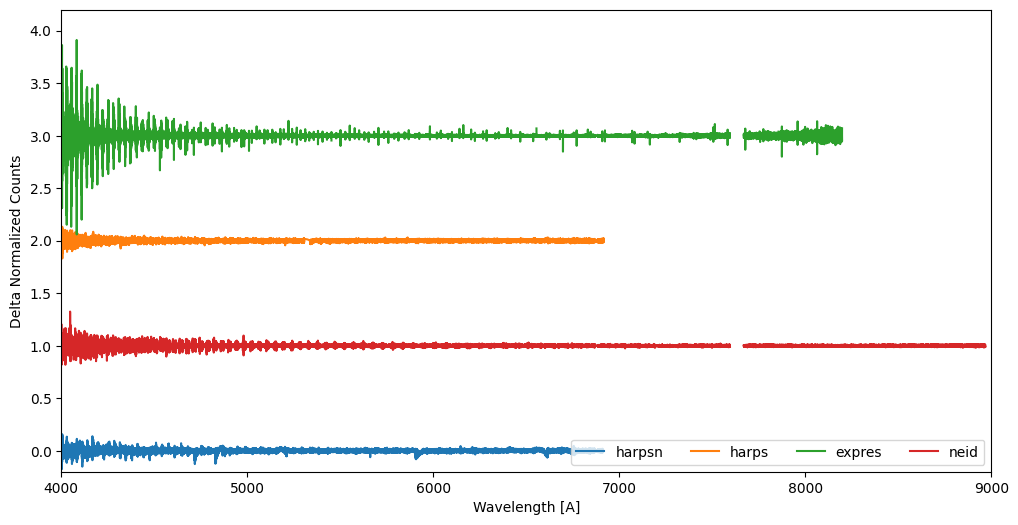

In [15]:
plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Delta Normalized Counts')

for inst in ['harpsn','harps','expres','neid']:

    if inst == 'harpsn':
        offset = 0
    elif inst == 'neid':
        offset = 1
    elif inst == 'harps':
        offset = 2
    elif inst == 'expres':
        offset = 3

    files = glob(os.path.join(essp_dir, f'DS{dset_num}', 'Merged', f'DS{dset_num}*_{inst}.fits'))

    
    # Load first file
    hdus1 = fits.open(files[0])
    wave = hdus1['wavelength'].data.copy()
    spec1 = hdus1['flux'].data.copy()
    hdus1.close()
    # Load second file
    hdus2 = fits.open(files[20])
    spec2 = hdus2['flux'].data.copy()
    hdus2.close()
    
    plt.plot(wave, (spec1 - spec2) + offset, label=inst)
    plt.xlim(4000, 9000)
    plt.ylim(-0.2, 4.2)
plt.legend(loc=4, ncol=4)
plt.show()

NEID

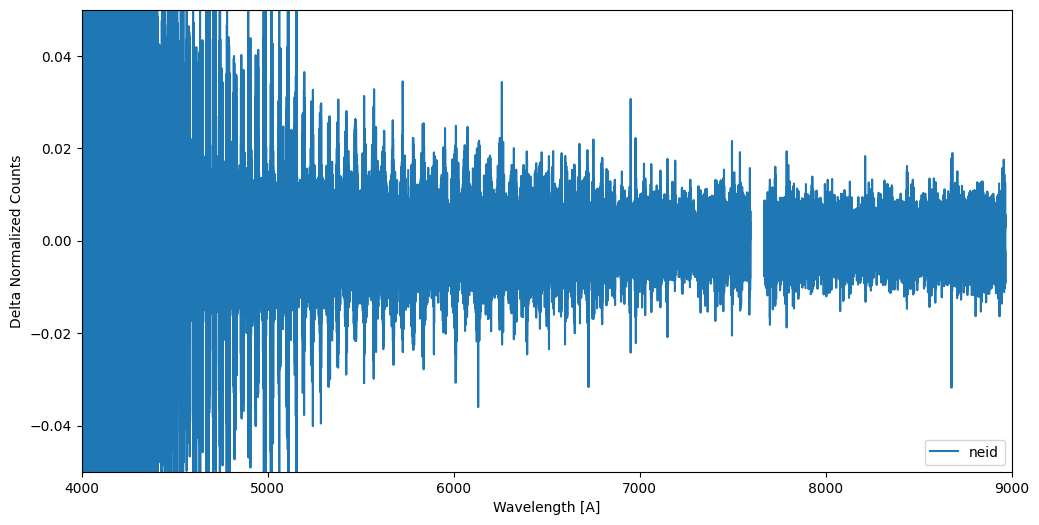

In [16]:
plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Delta Normalized Counts')

inst = 'neid'
offset = 1

files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}', 'Merged', f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
hdus1.close()
# Load second file
hdus2 = fits.open(files[20])
spec2 = hdus2['flux'].data.copy()
hdus2.close()

plt.plot(wave, (spec1 - spec2), label=inst)
# plt.xlim(4000, 9000)
plt.xlim(4000, 9000)
plt.ylim(-0.05, 0.05)
plt.legend(loc=4, ncol=1)
plt.show()

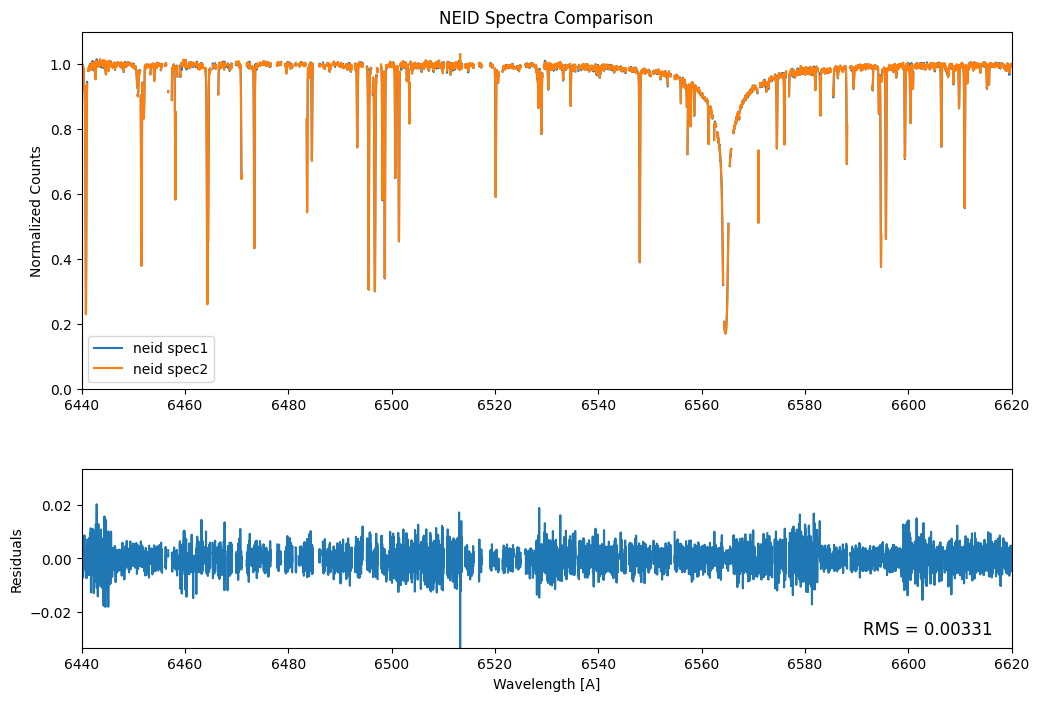

In [17]:
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(12, 8))
# Create a GridSpec with two rows, with the lower (difference) plot half the height of the upper
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

inst = 'neid'
# inst = 'expres'
offset = 1

files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}', 'Merged', f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
hdus1.close()
# Load second file
hdus2 = fits.open(files[1])
spec2 = hdus2['flux'].data.copy()
hdus2.close()

# Upper subplot: both spectra
ax0.plot(wave, spec1, label=f'{inst} spec1')
ax0.plot(wave, spec2, label=f'{inst} spec2')
ax0.set_ylabel('Normalized Counts')
ax0.set_xlim(6540, 6620)
ax0.set_ylim(-0, 1.1)
ax0.legend()
ax0.set_title('NEID Spectra Comparison')

# Lower subplot: difference
residual = spec1 - spec2
mask = (wave >= 6440) & (wave <= 6620)
masked_residual = residual[mask]
rms = np.sqrt(np.nanmean(masked_residual**2))
ax1.plot(wave, residual)
ax1.set_xlabel('Wavelength [A]')
ax1.set_ylabel('Residuals')
ax1.set_xlim(6440, 6620)
ax1.set_ylim(-rms * 10, rms * 10)

# Annotate RMS in the lower plot
ax1.text(0.98, 0.05, f'RMS = {rms:.5f}', ha='right', va='bottom', fontsize=12,
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

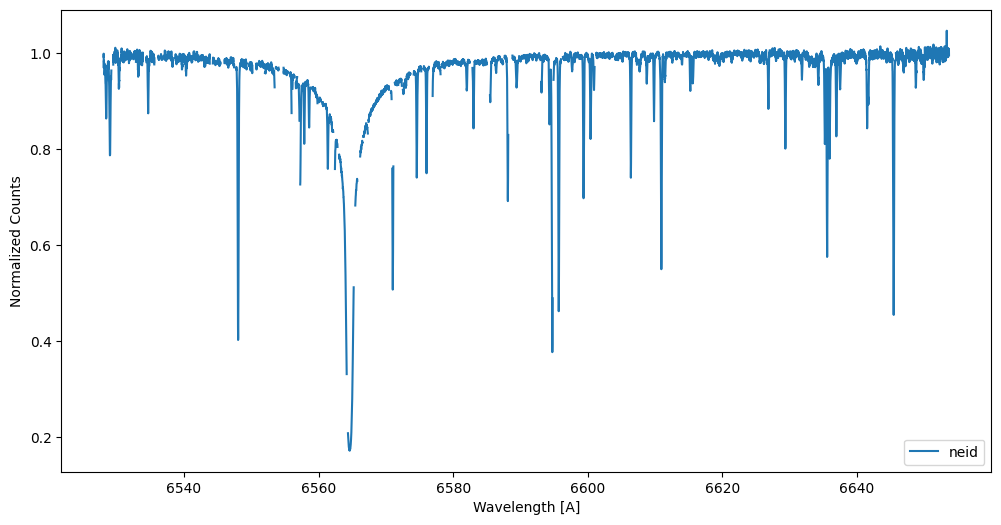

In [18]:
plt.figure(figsize=(12,6))
plt.xlabel('Wavelength [A]')
plt.ylabel('Normalized Counts')
# for iinst,inst in enumerate(['harpsn','harps','expres','neid']):
for iinst,inst in enumerate(['neid']):
    file = np.random.choice(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
    hdus = fits.open(file)
    wave = hdus['wavelength'].data.copy()
    spec = hdus['flux'].data.copy()
    cont = hdus['continuum'].data.copy()
    tmask = hdus['telluric_mask'].data.copy()
    hdus.close()
    
    plt.plot(wave[nord],spec[nord]/cont[nord]+iinst,label=inst)
    # plt.plot(wave,spec/cont+iinst,label=inst)
    # plt.fill_between(wave[nord],iinst,iinst+tmask[nord],color=f'C{iinst}',alpha=0.25)
# plt.xlim(6535,6590)
# plt.ylim(0,4)
plt.legend(loc=4,ncol=4)

In [19]:
1/10**2.5

0.003162277660168379

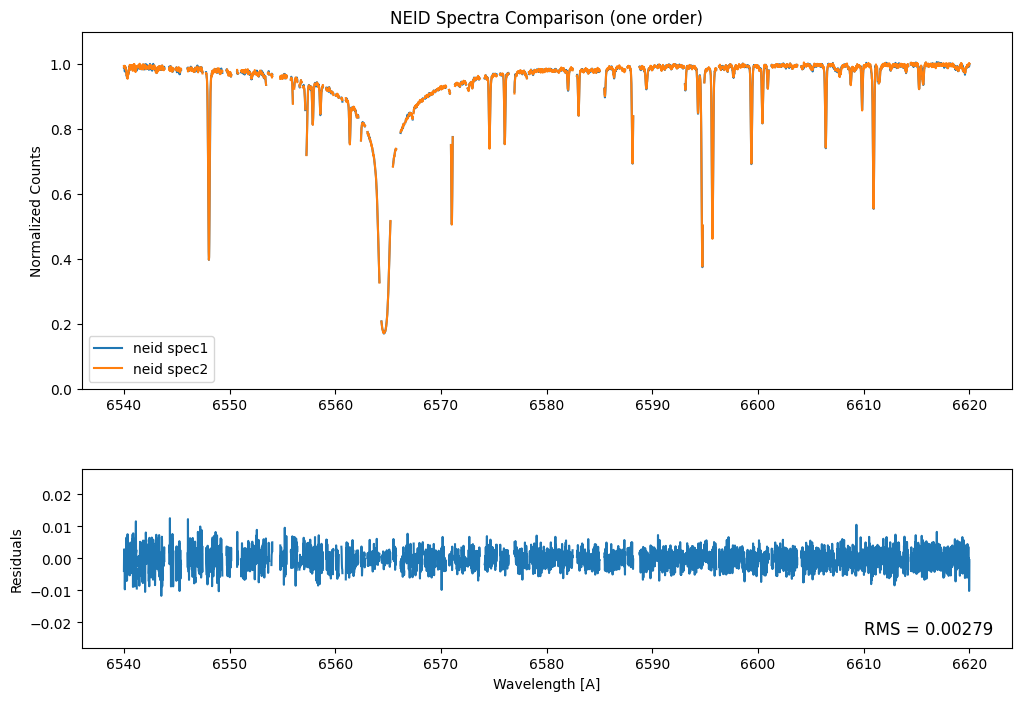

In [10]:
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

inst = 'neid'

# files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}', 'Merged', f'DS{dset_num}*_{inst}.fits')))
files = sorted(glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
cont1 = hdus1['continuum'].data.copy()
hdus1.close()

# Load second file
hdus2 = fits.open(files[1])
spec2 = hdus2['flux'].data.copy()
cont2 = hdus2['continuum'].data.copy()
hdus2.close()

# Use one order, as in the earlier code.
nord = 161-93 # for example; set this variable as in your main code if defined elsewhere

wave_ord = wave[nord]
spec1_ord = spec1[nord] / cont1[nord]
spec2_ord = spec2[nord] / cont2[nord]

mask = (wave_ord >= 6540) & (wave_ord <= 6620)
wave_ord = wave_ord[mask]
spec1_ord = spec1_ord[mask]
spec2_ord = spec2_ord[mask]

# Upper subplot: both spectra (only one order)
ax0.plot(wave_ord, spec1_ord, '-', label=f'{inst} spec1')
ax0.plot(wave_ord, spec2_ord, '-', label=f'{inst} spec2')
ax0.set_ylabel('Normalized Counts')
ax0.set_ylim(-0, 1.1)
ax0.legend()
ax0.set_title('NEID Spectra Comparison (one order)')

# Lower subplot: difference
residual = spec1_ord - spec2_ord
rms = np.sqrt(np.nanmean(residual**2))
ax1.plot(wave_ord, residual)
ax1.set_xlabel('Wavelength [A]')
ax1.set_ylabel('Residuals')
ax1.set_ylim(-rms * 10, rms * 10)
ax1.text(0.98, 0.05, f'RMS = {rms:.5f}', ha='right', va='bottom', fontsize=12,
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

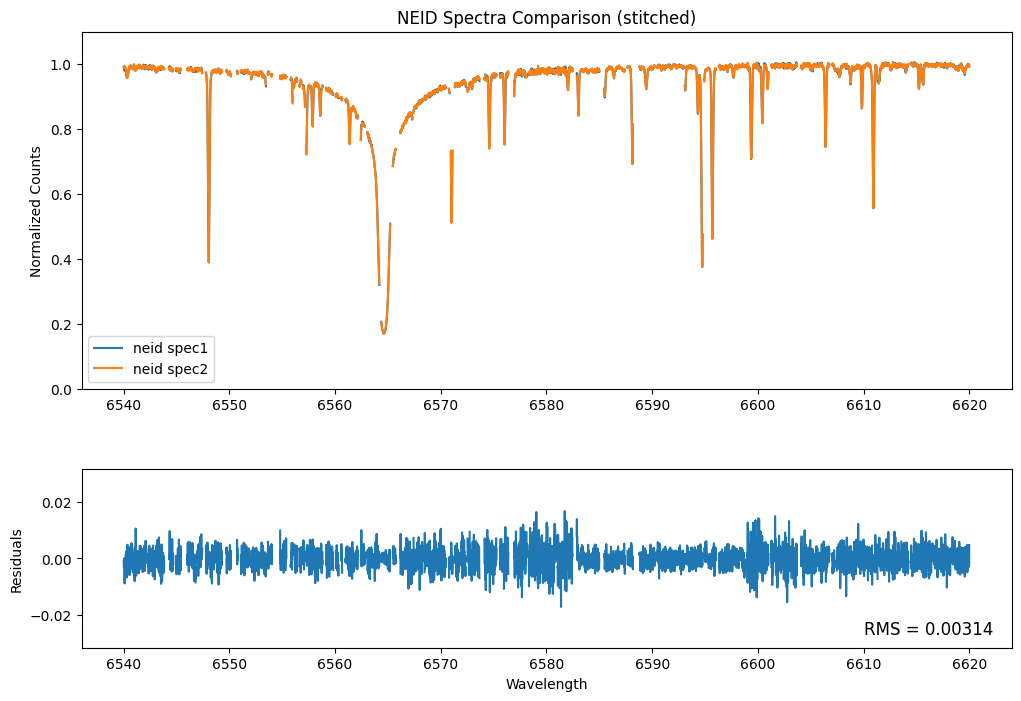

In [21]:
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(12, 8))
# Create a GridSpec with two rows, with the lower (difference) plot half the height of the upper
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

inst = 'neid'
# inst = 'expres'
offset = 1

files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}', 'Merged', f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
# spec1 = np.nan_to_num(hdus1['flux'].data.copy(), nan=1)
hdus1.close()
# Load second file
hdus2 = fits.open(files[1])
spec2 = hdus2['flux'].data.copy()
# spec2 = np.nan_to_num(hdus2['flux'].data.copy(), nan=1)
hdus2.close()

mask = (wave >= 6540) & (wave <= 6620)
# mask = (wave >= 0) & (wave <= 10000)
# wave = np.log10(wave[mask])
wave = wave[mask]
spec1 = spec1[mask]
spec2 = spec2[mask]

# Upper subplot: both spectra
ax0.plot(wave, spec1, '-', label=f'{inst} spec1')
ax0.plot(wave, spec2, '-', label=f'{inst} spec2')
ax0.set_ylabel('Normalized Counts')
# ax0.set_xlim(6540, 6620)
ax0.set_ylim(-0, 1.1)
ax0.legend()
ax0.set_title('NEID Spectra Comparison (stitched)')

# Lower subplot: difference
residual = spec1 - spec2

# masked_residual = residual[mask]
rms = np.sqrt(np.nanmean(residual**2))
ax1.plot(wave, residual)
# ax1.set_xlabel('log10 Wavelength')
ax1.set_xlabel('Wavelength')
ax1.set_ylabel('Residuals')
# ax1.set_xlim(6540, 6620)
ax1.set_ylim(-rms * 10, rms * 10)

# Annotate RMS in the lower plot
ax1.text(0.98, 0.05, f'RMS = {rms:.5f}', ha='right', va='bottom', fontsize=12,
         transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

In [42]:
import bindensity

def bind_resample(wave, spec, errs, wnew=default_wnew, err_cut=None):
    """
    Interpolate a spectrum on a new wavelength solution with bindensity.
    (Credit: YinNan)
    
    Parameters
    ----------
    wave, spec, errs : array, floats
       wavelength, flux, and associated errors of spectrum to be interpolated
    wnew : array, floats
        Values of new wavelength solution
    err_cut : array, float
        If given, spectral values with errors above this level will be masked out
    
    Returns
    ----------
    wnew, snew, enew: array, floats
        Spectral values and associated errors of the interpolated spectrum
    """
    # Flatten Input Data
    warr = wave.flatten()
    wsort = np.argsort(warr)
    sarr, earr = spec.flatten()[wsort], errs.flatten()[wsort]
    warr = warr[wsort]
    # Error Cut if Given
    if err_cut is not None:
        e_mask = earr<err_cut
        warr, sarr, earr = warr[e_mask], sarr[e_mask], earr[e_mask] 

    # Pad wavelengths w/ "last fence post"
    warr_tmp = np.append(warr,warr[-1]+np.diff(warr)[-1])
    wnew_tmp = np.append(wnew,wnew[-1]+np.diff(wnew)[-1])

    snew, cov_new = bindensity.resampling(wnew_tmp, warr_tmp, sarr,
                                          np.array([earr**2]), kind='cubic')
    return wnew, snew, np.sqrt(cov_new[0])

wmin, wmax, wdiff = min(wave), max(wave), 0.01
default_wnew = np.logspace(np.log10(wmin),np.log10(wmax),int((wmax-wmin)/wdiff+1))
errs = np.ones_like(spec1) * (spec1 * 10**5)**0.5 / 10**5
wave_resampled, spec_resampled, errs_resampled = bind_resample(wave, spec1, errs, wnew=default_wnew, err_cut=None)







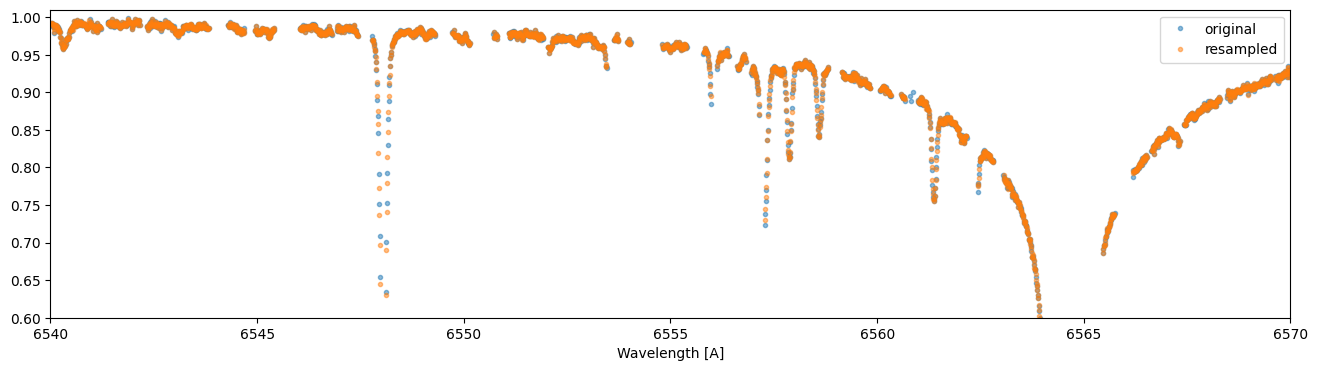

In [63]:
fig = plt.figure(figsize=(16, 4))
plt.plot(wave, spec1, '.', alpha=0.5, label='original')
plt.plot(wave_resampled, spec_resampled, '.', alpha=0.5, label='resampled')
plt.ylim(0.6, 1.01)
plt.xlim(6540, 6570)
plt.xlabel('Wavelength [A]')
plt.legend()
plt.show()





In [37]:
nan_idx1 = np.where(np.isnan(spec1_ord))[0]
nan_idx2 = np.where(np.isnan(spec2_ord))[0]
nan_idx = np.union1d(nan_idx1, nan_idx2)
nan_idx
spec1_ord[nan_idx]
spec2_ord[nan_idx]
spec1_ord = np.delete(spec1_ord, nan_idx)
spec2_ord = np.delete(spec2_ord, nan_idx)
wave_ord = np.delete(wave_ord, nan_idx)

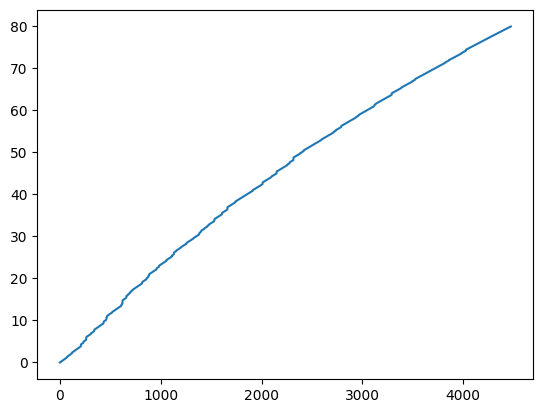

In [43]:
plt.plot(wave_ord - wave_ord[0])
plt.show()

In [12]:
# from glob import glob
# import os
# essp_dir = '/work2/lbuc/data/ESSP4/ESSP4'
# dset_num = 1
# inst = 'neid'

# files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))
files

['/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.007_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.008_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.009_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.016_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.017_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.018_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.024_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.025_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.026_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.033_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.034_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.035_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.051_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.052_spec_neid.fits',
 '/work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.0

In [6]:
# Load first file
inst = 'neid'
files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
cont1 = hdus1['continuum'].data.copy()
hdus1.info()
hdus1.close()

Filename: /work2/lbuc/data/ESSP4/ESSP4/DS1/Spectra/DS1.007_spec_neid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      21   ()      
  1  WAVELENGTH    1 ImageHDU         8   (9216, 93)   float64   
  2  FLUX          1 ImageHDU         8   (9216, 93)   float64   
  3  UNCERTAINTY    1 ImageHDU         8   (9216, 93)   float32   
  4  CONTINUUM     1 ImageHDU         8   (9216, 93)   float64   
  5  BLAZE         1 ImageHDU         8   (9216, 93)   float32   
  6  COMMON_MASK    1 ImageHDU         8   (9216, 93)   int64   
  7  TELLURIC_MASK    1 ImageHDU         8   (9216, 93)   int64   


In [6]:
# Use one order, as in the earlier code.
# nord = 161-93 # for example; set this variable as in your main code if defined elsewhere
nord = 161-96 # for example; set this variable as in your main code if defined elsewhere

In [7]:
def wrap(ϕ):
	'''	
	An individual phase ranges within (-np.pi, np.pi)
	The difference of two phases ranges within (-2*np.pi, 2*np.pi)
	Adding multiples of 2*np.pi to the phase is effectively the same phase
	This function wraps Δϕ such that it lies within (-np.pi, np.pi)
	'''		
	for i in np.arange(len(ϕ)):
		ϕ[i] = ϕ[i] - int(ϕ[i]/np.pi) * 2 * np.pi
	return ϕ

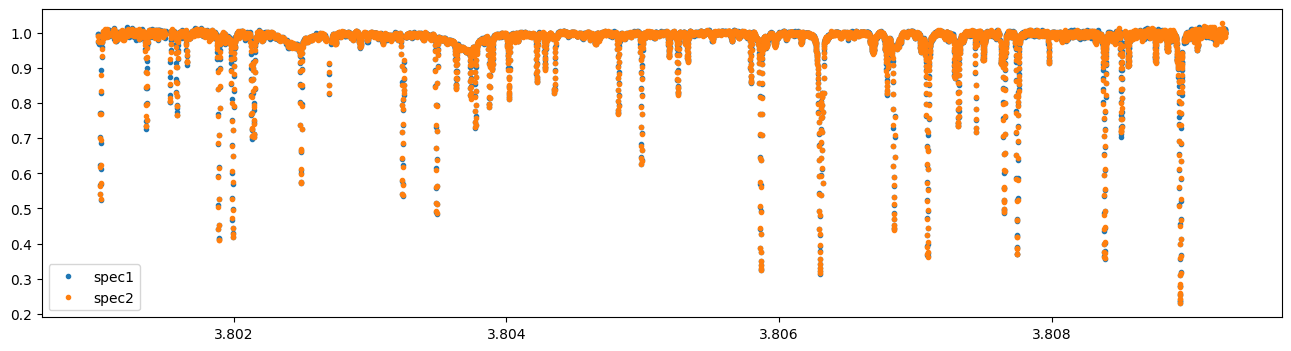

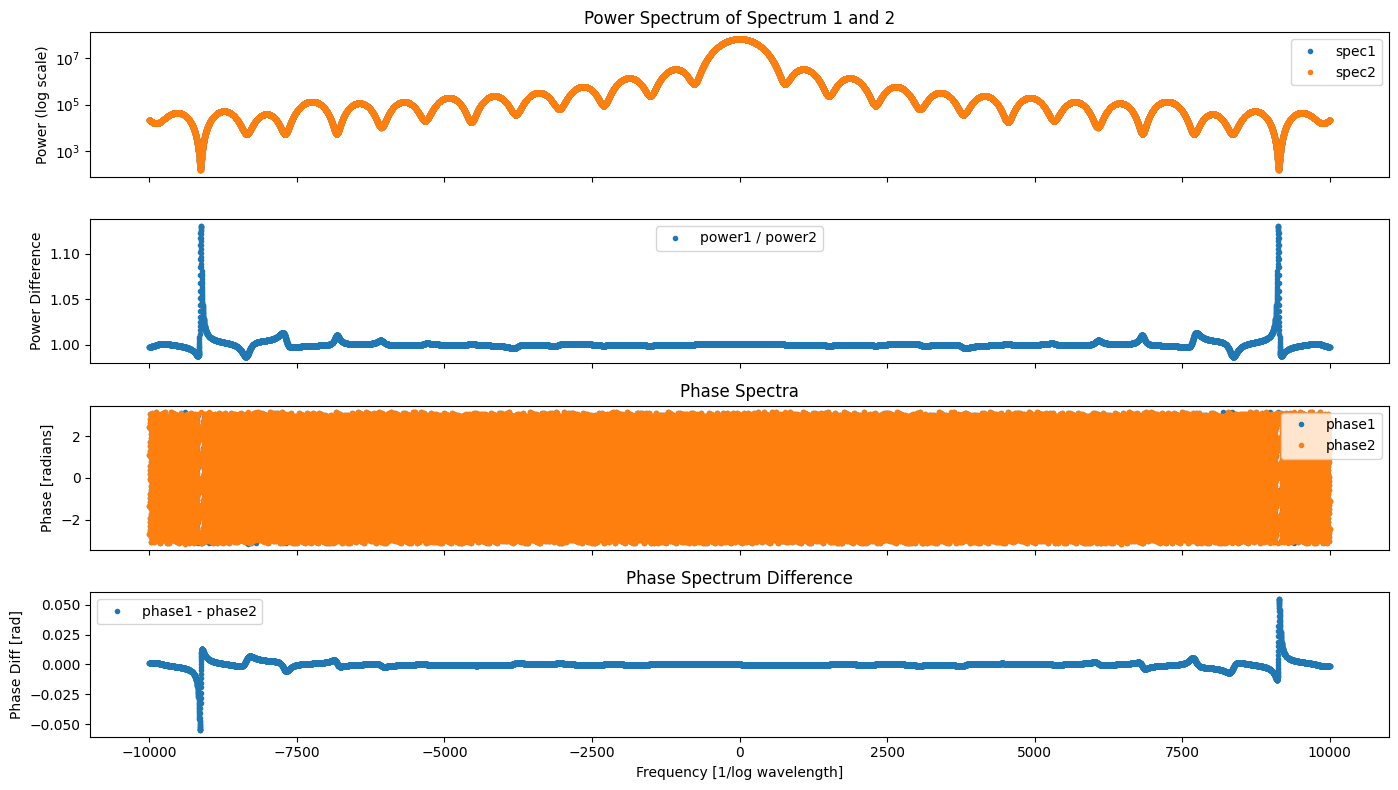

In [8]:
from finufft import nufft1d3

# Load first file
inst = 'neid'
files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
cont1 = hdus1['continuum'].data.copy()
hdus1.close()

# Load second file
hdus2 = fits.open(files[1])
spec2 = hdus2['flux'].data.copy()
cont2 = hdus2['continuum'].data.copy()
hdus2.close()

wave_ord = wave[nord]
spec1_ord = spec1[nord] / cont1[nord]
spec2_ord = spec2[nord] / cont2[nord]

# mask = (wave_ord >= 6540) & (wave_ord <= 6620)
# wave_ord = wave_ord[mask]
wave_ord = np.log10(wave_ord)
# spec1_ord = spec1_ord[mask]
# spec2_ord = spec2_ord[mask]

nan_idx1 = np.where(np.isnan(spec1_ord))[0]
nan_idx2 = np.where(np.isnan(spec2_ord))[0]
nan_idx = np.union1d(nan_idx1, nan_idx2)
spec1_ord = np.delete(spec1_ord, nan_idx)
spec2_ord = np.delete(spec2_ord, nan_idx)
wave_ord = np.delete(wave_ord, nan_idx)

fig = plt.figure(figsize=(16, 4))
plt.plot(wave_ord, spec1_ord, '.', label='spec1')
plt.plot(wave_ord, spec2_ord, '.', label='spec2')
plt.legend()
plt.show()

# --- Ensure float dtype for FINUFFT compatibility ---
wave_ord = wave_ord.astype(np.float64)
spec1_ord = spec1_ord.astype(np.complex128)
spec2_ord = spec2_ord.astype(np.complex128)

# Define uniform frequency grid where we want output
frequencies = np.linspace(-10000, 10000, 20000).astype(np.float64)

# Compute NUFFT for original and shifted signals
# (Note: nufft1d3(x, c, s) requires x and s to be float32 or float64, c to be complex64 or complex128)
spectrum1 = nufft1d3(wave_ord, spec1_ord, frequencies)
spectrum2 = nufft1d3(wave_ord, spec2_ord, frequencies)

# Extract spectral information
magnitude1 = np.abs(spectrum1)
phase1 = np.angle(spectrum1)
power1 = np.abs(spectrum1)**2

magnitude2 = np.abs(spectrum2)
phase2 = np.angle(spectrum2)
power2 = np.abs(spectrum2)**2

# For plotting, use "frequencies" instead of "freqs"
freqs = frequencies

# Create 4 subplots: Power spectra, Power diff, Phase spectra, Phase difference
fig, (ax_top, ax_mid, ax_phase, ax_bot) = plt.subplots(4, 1, figsize=(14, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 1, 1, 1]})

# Upper subplot: log power spectra
ax_top.semilogy(freqs, power1, '.', label='spec1')
ax_top.semilogy(freqs, power2, '.', label='spec2')
ax_top.set_ylabel('Power (log scale)')
ax_top.set_title('Power Spectrum of Spectrum 1 and 2')
ax_top.legend()

# Middle subplot: difference of the power spectra (normal scale)
power_diff = power1 / power2
ax_mid.plot(freqs, power_diff, '.', label='power1 / power2')
ax_mid.set_ylabel('Power Difference')
ax_mid.legend()

# Third subplot: phase spectra
ax_phase.plot(freqs, phase1, '.', label='phase1')
ax_phase.plot(freqs, phase2, '.', label='phase2')
ax_phase.set_ylabel('Phase [radians]')
ax_phase.set_title('Phase Spectra')
ax_phase.legend()

phase_diff = wrap(phase1-phase2)
# phase_diff = phase1-phase2
# Bottom subplot: phase difference
ax_bot.plot(freqs, phase_diff, '.', label='phase1 - phase2')
ax_bot.set_xlabel('Frequency [1/log wavelength]')
ax_bot.set_ylabel('Phase Diff [rad]')
ax_bot.set_title('Phase Spectrum Difference')
ax_bot.legend()

plt.tight_layout()
plt.show()

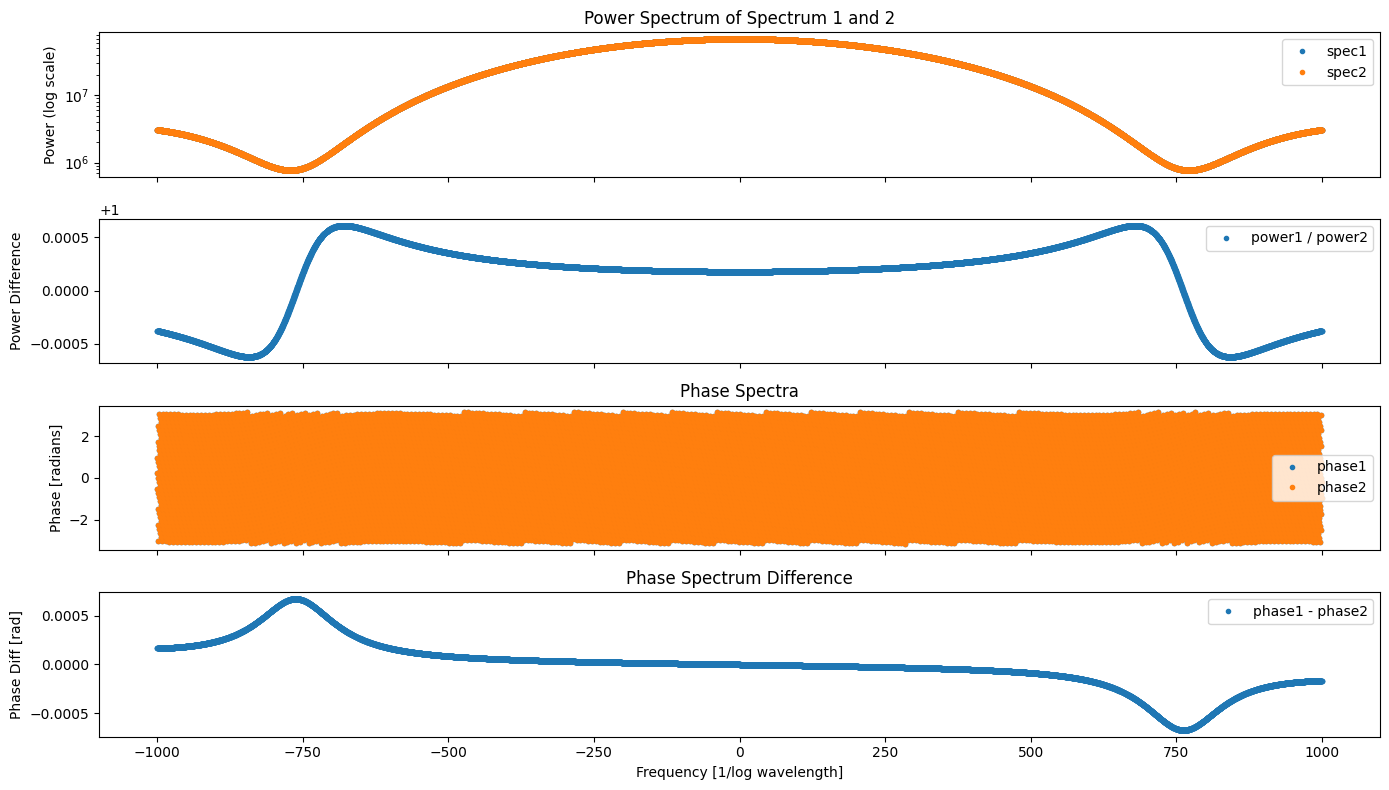

In [9]:
# Define uniform frequency grid where we want output
frequencies = np.linspace(-1000, 1000, 10001).astype(np.float64)

# Compute NUFFT for original and shifted signals
# (Note: nufft1d3(x, c, s) requires x and s to be float32 or float64, c to be complex64 or complex128)
spectrum1 = nufft1d3(wave_ord, spec1_ord, frequencies)
spectrum2 = nufft1d3(wave_ord, spec2_ord, frequencies)

# Extract spectral information
magnitude1 = np.abs(spectrum1)
phase1 = np.angle(spectrum1)
power1 = np.abs(spectrum1)**2

magnitude2 = np.abs(spectrum2)
phase2 = np.angle(spectrum2)
power2 = np.abs(spectrum2)**2

# For plotting, use "frequencies" instead of "freqs"
freqs = frequencies

# Create 4 subplots: Power spectra, Power diff, Phase spectra, Phase difference
fig, (ax_top, ax_mid, ax_phase, ax_bot) = plt.subplots(4, 1, figsize=(14, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 1, 1, 1]})

# Upper subplot: log power spectra
ax_top.semilogy(freqs, power1, '.', label='spec1')
ax_top.semilogy(freqs, power2, '.', label='spec2')
ax_top.set_ylabel('Power (log scale)')
ax_top.set_title('Power Spectrum of Spectrum 1 and 2')
ax_top.legend()

# Middle subplot: difference of the power spectra (normal scale)
power_diff = power1 / power2
ax_mid.plot(freqs, power_diff, '.', label='power1 / power2')
ax_mid.set_ylabel('Power Difference')
ax_mid.legend()

# Third subplot: phase spectra
ax_phase.plot(freqs, phase1, '.', label='phase1')
ax_phase.plot(freqs, phase2, '.', label='phase2')
ax_phase.set_ylabel('Phase [radians]')
ax_phase.set_title('Phase Spectra')
ax_phase.legend()

# Bottom subplot: phase difference
ax_bot.plot(freqs, phase1-phase2, '.', label='phase1 - phase2')
ax_bot.set_xlabel('Frequency [1/log wavelength]')
ax_bot.set_ylabel('Phase Diff [rad]')
ax_bot.set_title('Phase Spectrum Difference')
ax_bot.legend()

plt.tight_layout()
plt.show()

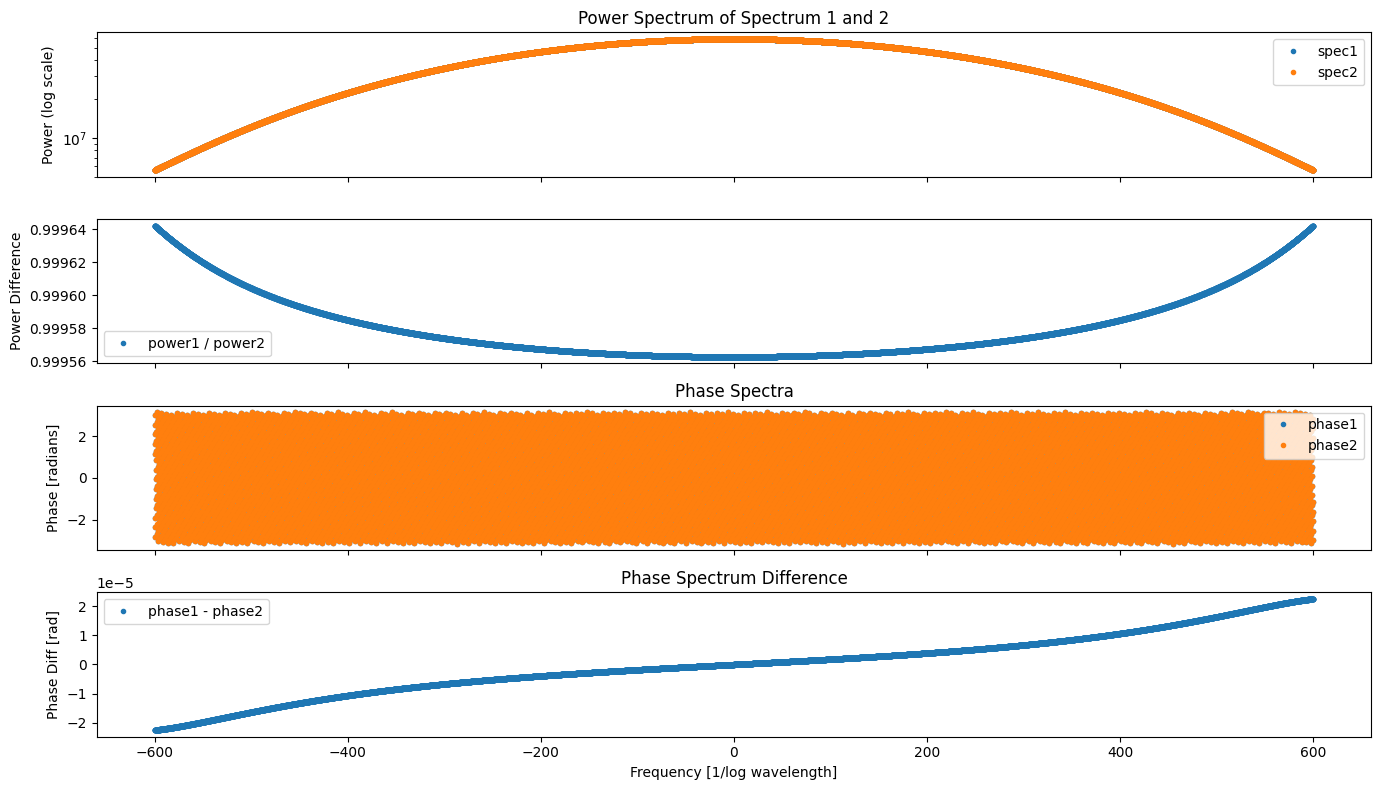

In [12]:
# Define uniform frequency grid where we want output
frequencies = np.linspace(-600, 600, 10001).astype(np.float64)

# Compute NUFFT for original and shifted signals
# (Note: nufft1d3(x, c, s) requires x and s to be float32 or float64, c to be complex64 or complex128)
spectrum1 = nufft1d3(wave_ord, spec1_ord, frequencies)
spectrum2 = nufft1d3(wave_ord, spec2_ord, frequencies)

# Extract spectral information
magnitude1 = np.abs(spectrum1)
phase1 = np.angle(spectrum1)
power1 = np.abs(spectrum1)**2

magnitude2 = np.abs(spectrum2)
phase2 = np.angle(spectrum2)
power2 = np.abs(spectrum2)**2

# For plotting, use "frequencies" instead of "freqs"
freqs = frequencies

# Create 4 subplots: Power spectra, Power diff, Phase spectra, Phase difference
fig, (ax_top, ax_mid, ax_phase, ax_bot) = plt.subplots(4, 1, figsize=(14, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 1, 1, 1]})

# Upper subplot: log power spectra
ax_top.semilogy(freqs, power1, '.', label='spec1')
ax_top.semilogy(freqs, power2, '.', label='spec2')
ax_top.set_ylabel('Power (log scale)')
ax_top.set_title('Power Spectrum of Spectrum 1 and 2')
ax_top.legend()

# Middle subplot: difference of the power spectra (normal scale)
power_diff = power1 / power2
ax_mid.plot(freqs, power_diff, '.', label='power1 / power2')
ax_mid.set_ylabel('Power Difference')
ax_mid.legend()

# Third subplot: phase spectra
ax_phase.plot(freqs, phase1, '.', label='phase1')
ax_phase.plot(freqs, phase2, '.', label='phase2')
ax_phase.set_ylabel('Phase [radians]')
ax_phase.set_title('Phase Spectra')
ax_phase.legend()

# Bottom subplot: phase difference
ax_bot.plot(freqs, phase1-phase2, '.', label='phase1 - phase2')
ax_bot.set_xlabel('Frequency [1/log wavelength]')
ax_bot.set_ylabel('Phase Diff [rad]')
ax_bot.set_title('Phase Spectrum Difference')
ax_bot.legend()

plt.tight_layout()
plt.show()

In [13]:
delta_log = max(phase1-phase2) / 600 / (-2*np.pi)
delta_log

-5.979868742212337e-09

In [14]:
(10**delta_log -1)* 3e8

-4.130746944497332

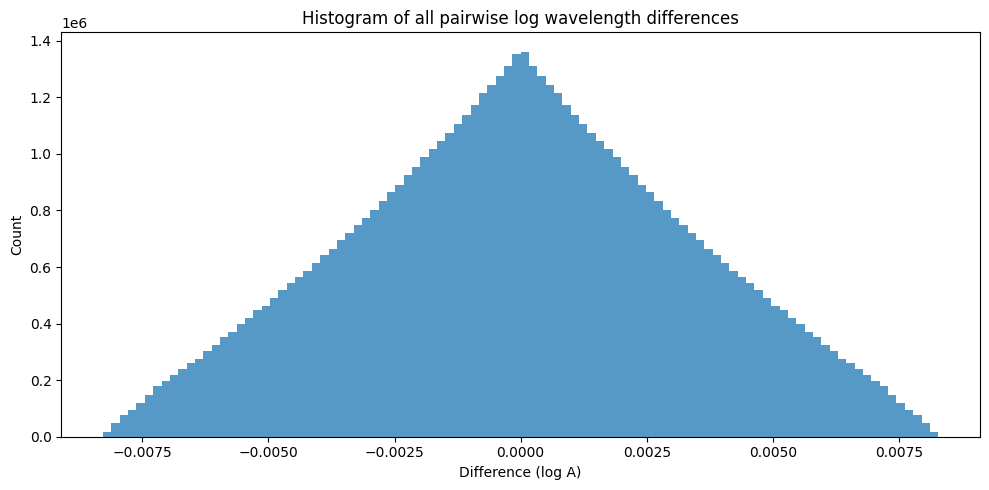

(0.008279390687302435,
 6.231840723458504e-07,
 120.78183501276673,
 1604662.3210951176)

In [39]:
diff_combinations = wave_ord[:, None] - wave_ord[None, :]

plt.figure(figsize=(10,5))
plt.hist(diff_combinations.flatten(), bins=100, color='C0', alpha=0.75)
plt.xlabel('Difference (log A)')
plt.ylabel('Count')
plt.title('Histogram of all pairwise log wavelength differences')
plt.tight_layout()
plt.show()

max(wave_ord)-min(wave_ord), min(np.diff(wave_ord)), 1/(max(wave_ord)-min(wave_ord)), 1/min(np.diff(wave_ord))



In [23]:
if 0:
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import interp1d

    # Irregular sampling
    x_irregular = np.sort(np.random.uniform(0, 2 * np.pi, 100))
    y = np.sin(3 * x_irregular) + 0.5 * np.sin(7 * x_irregular)

    # Shift the signal by a small amount
    shift = 0.01  # small shift
    x_irregular_shifted = x_irregular + shift
    # Keep within [0, 2pi] bounds if needed:
    x_irregular_shifted = np.clip(x_irregular_shifted, x_irregular[0], x_irregular[-1])
    y_shifted = y

    # Show what the signals look like
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(x_irregular, y, 'o-', label='Original')
    plt.plot(x_irregular_shifted, y_shifted, 'o-', label='Shifted', alpha=0.7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Signal on Irregular Grid")
    plt.legend()

    # Interpolate onto a uniform grid for visualization and FFT
    x_uniform = np.linspace(
        min(x_irregular.min(), x_irregular_shifted.min()), 
        max(x_irregular.max(), x_irregular_shifted.max()), 
        200
    )
    interp_func = interp1d(x_irregular, y, kind='linear', fill_value='extrapolate')
    y_uniform = interp_func(x_uniform)
    interp_func_shifted = interp1d(x_irregular_shifted, y_shifted, kind='linear', fill_value='extrapolate')
    y_uniform_shifted = interp_func_shifted(x_uniform)

    plt.subplot(1, 2, 2)
    plt.plot(x_irregular, y, 'o', label='Original', alpha=0.5)
    plt.plot(x_irregular_shifted, y_shifted, 'o', label='Shifted', alpha=0.5)
    plt.plot(x_uniform, y_uniform, '-', label='Interpolated (Original)')
    plt.plot(x_uniform, y_uniform_shifted, '-', label='Interpolated (Shifted)', alpha=0.7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolated Signals (Uniform Grid)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # FFT spectrum analysis

    # Define uniform frequency grid where we want output
    frequencies = np.linspace(-10, 10, 200)

    # Compute the FFTs
    fft_vals = np.fft.fft(y_uniform)
    fft_vals_shifted = np.fft.fft(y_uniform_shifted)
    fft_freqs = np.fft.fftfreq(len(y_uniform), d=(x_uniform[1] - x_uniform[0]))

    # Interpolation for magnitude, power, phase to match requested frequencies
    magnitude_interp = interp1d(fft_freqs, np.abs(fft_vals), kind='linear', bounds_error=False, fill_value=0)
    power_interp = interp1d(fft_freqs, np.abs(fft_vals)**2, kind='linear', bounds_error=False, fill_value=0)
    phase_interp = interp1d(fft_freqs, np.angle(fft_vals), kind='linear', bounds_error=False, fill_value=0)

    magnitude_interp_shifted = interp1d(fft_freqs, np.abs(fft_vals_shifted), kind='linear', bounds_error=False, fill_value=0)
    power_interp_shifted = interp1d(fft_freqs, np.abs(fft_vals_shifted)**2, kind='linear', bounds_error=False, fill_value=0)
    phase_interp_shifted = interp1d(fft_freqs, np.angle(fft_vals_shifted), kind='linear', bounds_error=False, fill_value=0)

    magnitude = magnitude_interp(frequencies)
    magnitude_shifted = magnitude_interp_shifted(frequencies)
    power = power_interp(frequencies)
    power_shifted = power_interp_shifted(frequencies)
    phase = phase_interp(frequencies)
    phase_shifted = phase_interp_shifted(frequencies)

    # Plot spectra and their differences
    plt.figure(figsize=(22, 4))

    plt.subplot(1, 4, 1)
    plt.plot(frequencies, magnitude, label='Original')
    plt.plot(frequencies, magnitude_shifted, label='Shifted', alpha=0.7)
    plt.title('Magnitude Spectrum')
    plt.xlabel('Frequency')
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(frequencies, power, label='Original')
    plt.plot(frequencies, power_shifted, label='Shifted', alpha=0.7)
    plt.title('Power Spectrum')
    plt.xlabel('Frequency')
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(frequencies, phase, label='Original')
    plt.plot(frequencies, phase_shifted, label='Shifted', alpha=0.7)
    plt.title('Phase Spectrum')
    plt.xlabel('Frequency')
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(frequencies, magnitude - magnitude_shifted, label='Magnitude Diff')
    plt.plot(frequencies, power - power_shifted, label='Power Diff')
    plt.plot(frequencies, phase - phase_shifted, label='Phase Diff')
    plt.title('Spectrum Differences')
    plt.xlabel('Frequency')
    plt.legend()

    plt.tight_layout()
    plt.show()


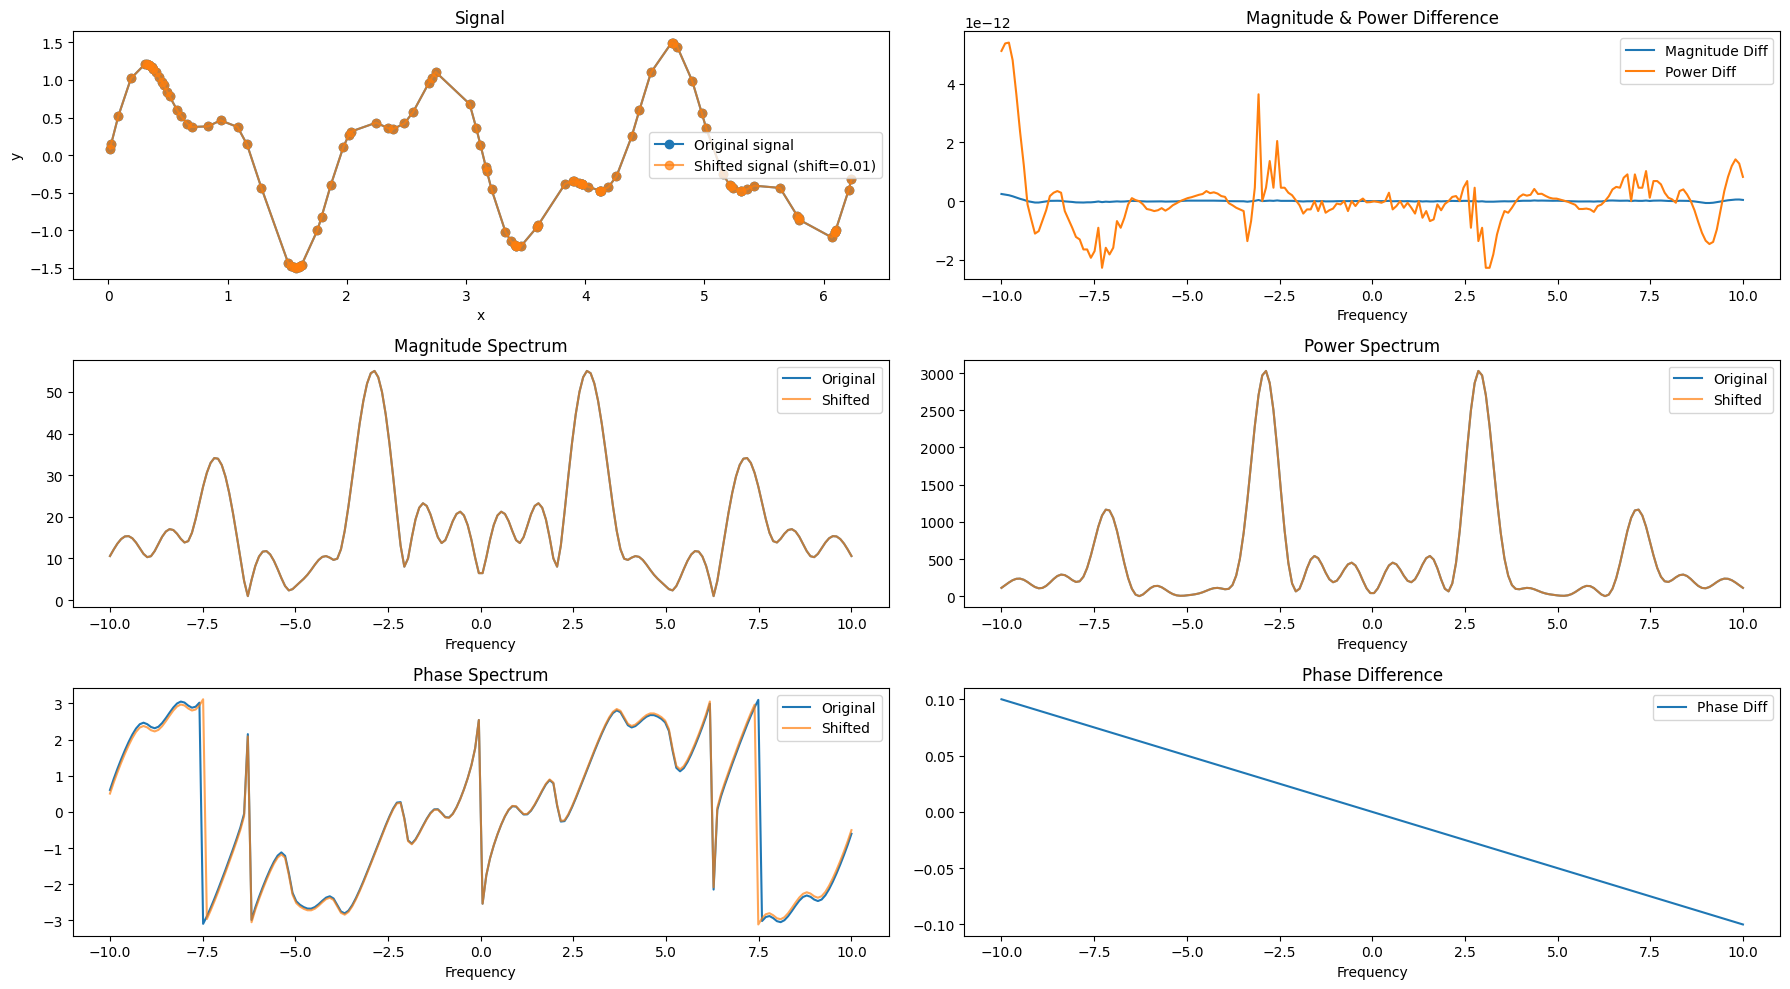

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from finufft import nufft1d3

# Irregular sampling
x_irregular = np.sort(np.random.uniform(0, 2*np.pi, 100))
y = np.sin(3 * x_irregular) + 0.5 * np.sin(7 * x_irregular)

# Create a shifted version of the signal
shift_amount = 0.01  # small shift
y_shifted = y

# Convert y to complex (NUFFT requires complex input)
y_complex = y.astype(np.complex128)
y_shifted_complex = y_shifted.astype(np.complex128)

# Define uniform frequency grid where we want output
frequencies = np.linspace(-10, 10, 200)

# Compute NUFFT for original and shifted signals
F = nufft1d3(x_irregular, y_complex, frequencies)
F_shifted = nufft1d3(x_irregular+shift_amount, y_complex, frequencies)

# Extract spectral information
magnitude = np.abs(F)
phase = np.angle(F)
power = np.abs(F)**2

magnitude_shifted = np.abs(F_shifted)
phase_shifted = np.angle(F_shifted)
power_shifted = np.abs(F_shifted)**2

plt.figure(figsize=(18, 10))

# Plot the irregularly sampled signals
plt.subplot(3, 2, 1)
plt.plot(x_irregular, y, 'o-', label='Original signal')
plt.plot(x_irregular, y_shifted, 'o-', label=f'Shifted signal (shift={shift_amount})', alpha=0.7)
plt.title('Signal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

# Spectral plots - Original vs Shifted
plt.subplot(3, 2, 3)
plt.plot(frequencies, magnitude, label='Original')
plt.plot(frequencies, magnitude_shifted, label='Shifted', alpha=0.7)
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency')
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(frequencies, power, label='Original')
plt.plot(frequencies, power_shifted, label='Shifted', alpha=0.7)
plt.title('Power Spectrum')
plt.xlabel('Frequency')
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(frequencies, phase, label='Original')
plt.plot(frequencies, phase_shifted, label='Shifted', alpha=0.7)
plt.title('Phase Spectrum')
plt.xlabel('Frequency')
plt.legend()

# Plot magnitude and power differences
plt.subplot(3, 2, 2)
plt.plot(frequencies, magnitude - magnitude_shifted, label='Magnitude Diff')
plt.plot(frequencies, power - power_shifted, label='Power Diff')
plt.title('Magnitude & Power Difference')
plt.xlabel('Frequency')
plt.legend()

# Plot phase difference in a separate plot
plt.subplot(3, 2, 6)
plt.plot(frequencies, np.unwrap(phase) - np.unwrap(phase_shifted), label='Phase Diff')
plt.title('Phase Difference')
plt.xlabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()


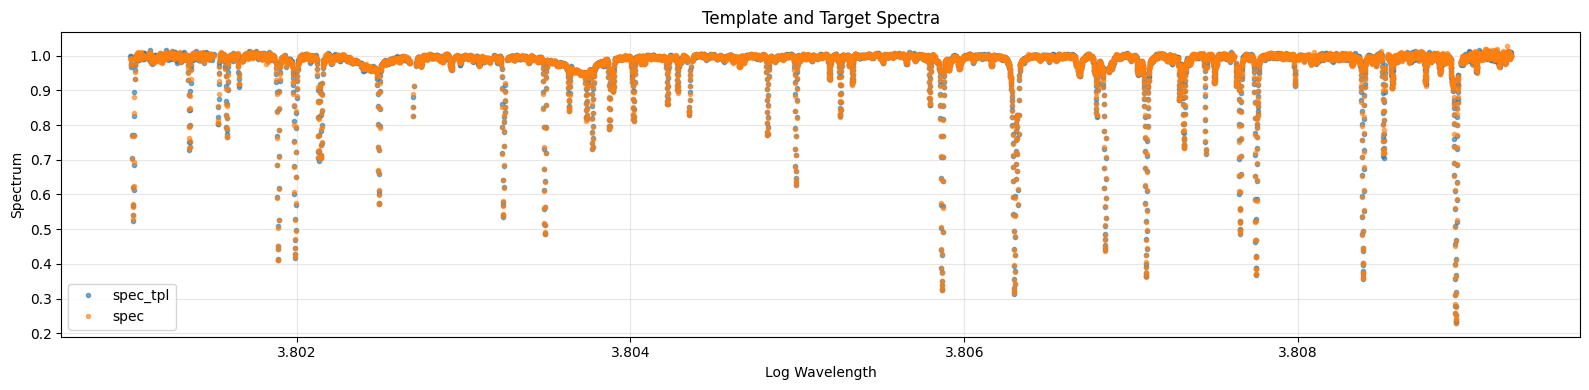

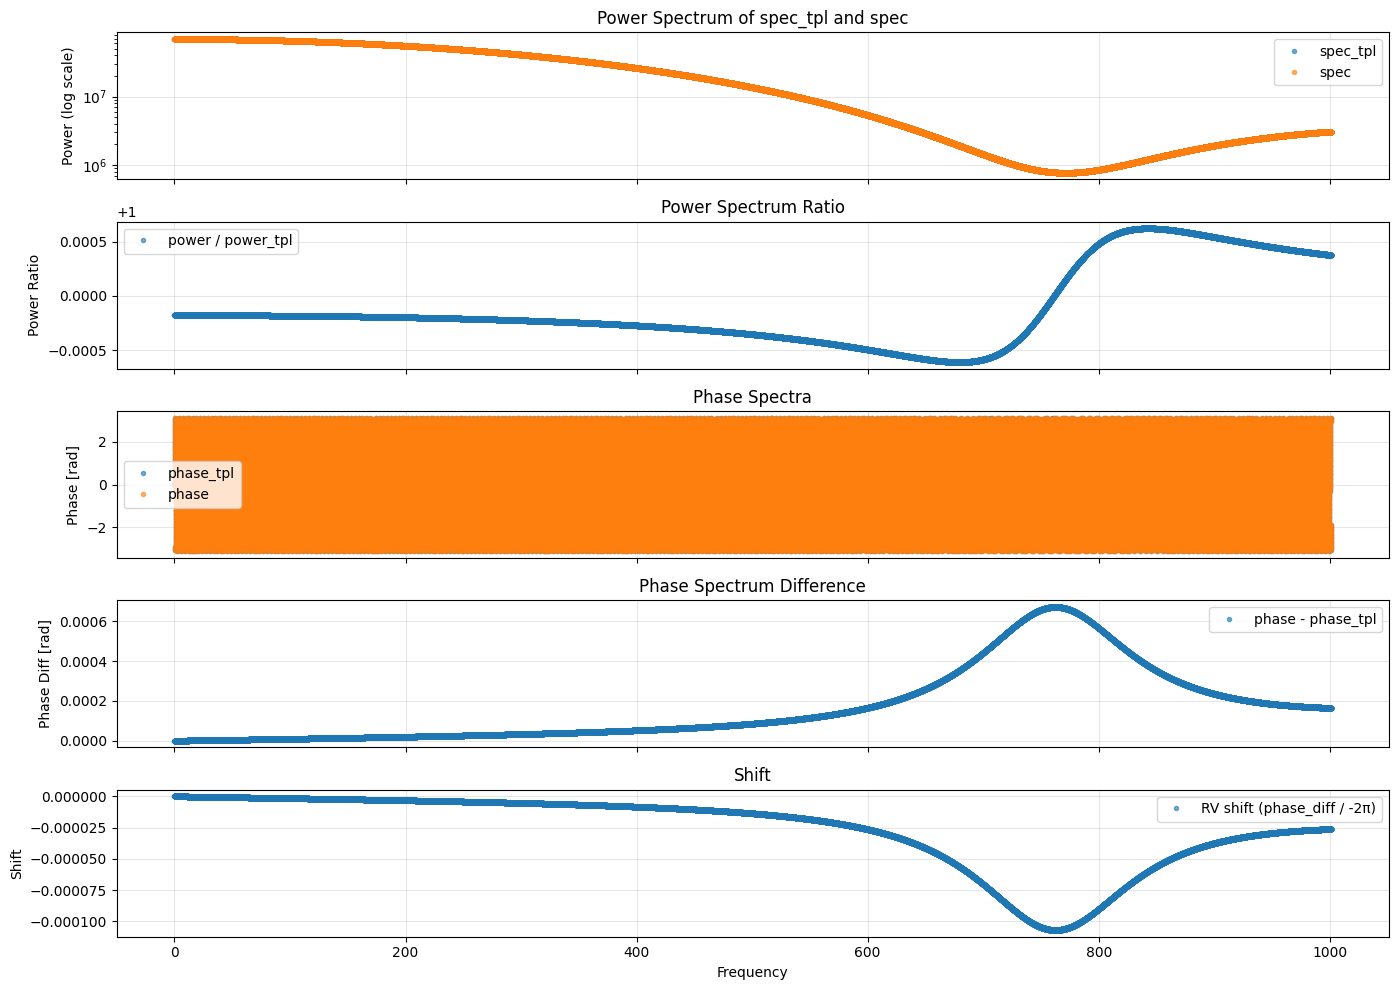

In [ ]:
import sys
import importlib.util

# Import FIESTA_III/FIESTA-III.py as a module
spec = importlib.util.spec_from_file_location("FIESTA_III_module", "/work2/lbuc/jzhao/PyORBIT_ESSP/FIESTA_III/FIESTA-III.py")
FIESTA_III_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(FIESTA_III_module)
FIESTA_III = FIESTA_III_module.FIESTA_III

results = FIESTA_III(wave_ord, spec1_ord, spec2_ord, 
                    freq_max=1001, n_freq=50001,
                    plot_template=True, 
                    plot_comparison=True)

In [ ]:
(10**results['rv_shift']-1)*3e8


-3726.8168847637285